# CL-ST: Identifying moldy peanut using hyperspectral imaging by correction of noisy labelling — hands-on reproduction (author demo, CPU)

**Paper**: Deshuai Yuan, Yanqing Xie, Wenchao Qi, Ruoxi Song, *"Identifying moldy peanut using hyperspectral imaging by correction of noisy labelling"*, **Food Research International 217 (2025) 116741**, doi:[10.1016/j.foodres.2025.116741](https://doi.org/10.1016/j.foodres.2025.116741)

**Author code**: https://github.com/yuandeshuai/CL-ST pinned at commit `8f03113a0245d5d36fe275bffee0b989a606b12e` (main.py + utils.py + original_data.rar), reproduced here with minimal reorganization.

**Scope (what this notebook does)**: runs the authors' own CL-ST demo end-to-end on their shipped hyperspectral demo data:
1. loads train/validation/test hyperspectral images (H×W×288 bands) with **weak pixel labels**,
2. indexes peanut kernels by region growing (`aquire_index`),
3. quantifies per-pixel **label quality** with CL-ST = out-of-sample probability (10-fold RF + sigmoid calibration) × statistical testing (**num = 20** repeats, cleanlab self-confidence),
4. visualizes label quality in PCA feature space,
5. sweeps the flip threshold over 100 values, retraining a random forest each step and computing pixel- and kernel-scale metrics (author's `A1` matrix),
6. rebuilds the classifier at the demo's `optimal_threshold = 0.95` / `optimal_PMP = 0.02` and reports pixel-level accuracy plus the kernel-scale confusion matrix.

**Not done here (out of demo scope)**: SPA band selection itself (band indices are precomputed in `main.py`), the paper's best **SPA-ELM** model (not implemented in the repository — the demo uses a random forest), and paper-level benchmark numbers. One demo run is not verification of the published dataset-level results (e.g. 74.63%→98.96% OA). The full paper text was not used; the executed path is fully specified by the pinned code.

**実行環境（ランタイム）**: このデモは CPU のみで実行できます（scikit-learn / cleanlab のみ使用、GPU 不要）。メニューバー「ランタイム」→「ランタイムのタイプを変更」→ **CPU** を選択してください。上から順に実行（Run all）で約 35–50 分かかります（主な内訳: CL-ST 品質推定 ~15 分、しきい値スイープ ~15–20 分）。

**実行内容（日本語概要）**: 著者公開の CL-ST デモ一式を、著者提供の高光谱データ（ピーナッツ・カビ判定）でそのまま再現します。弱ラベルの品質を CL-ST で推定し、低品質ラベルを最適しきい値で修正して分類器を再学習し、画素級・粒子級精度を報告します。

## 0. Environment check

The demo needs `cleanlab` (not preinstalled on Colab); everything else (numpy, scipy, scikit-learn, matplotlib, tqdm, opencv) is preinstalled or checked below. The authors used Python 3.10 with numpy 1.26 (README); this notebook runs on Colab's current Python.

環境確認セルです。cleanlab のみ追加インストールし、残りは Colab に事前インストール済みの版を使います。

In [ ]:
import sys, importlib
print('Python', sys.version.split()[0])
%pip -q install cleanlab 2>&1 | tail -1
import numpy, scipy, sklearn, matplotlib, tqdm, cleanlab
print('numpy', numpy.__version__, '| scipy', scipy.__version__, '| scikit-learn', sklearn.__version__,
      '| cleanlab', cleanlab.__version__)
try:
    import cv2  # used only for cv2.imwrite of the predicted kernel map, as in the authors' main.py
    print('opencv', cv2.__version__)
except ImportError:
    %pip -q install opencv-python-headless
    import cv2
    print('opencv (installed)', cv2.__version__)

Python 3.13.16


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 7.3 MB/s eta 0:00:00


numpy 2.1.3 | scipy 1.16.3 | scikit-learn 1.6.1 | cleanlab 2.9.0
opencv 5.0.0


## 1. Input data — author's `original_data.rar` (24.8 MB)

The demo data ships **inside the author repository** (blob `original_data.rar`, 24,834,766 bytes at the pinned commit). It is downloaded **here in Colab** from the pinned raw URL and verified by size and SHA-256 before use. SHA-256 `a9fe7f1f…b463b5` was measured on this exact blob during the validation run of this notebook (2026-10-09, Colab CPU); the file begins with the RAR signature `Rar!`.

データは著者リポジトリ同梱の `original_data.rar`（24,834,766 バイト）をピン留したコミットから Colab 内でダウンロードし、サイズと SHA-256 を検証します。

In [ ]:
import urllib.request, hashlib, os
COMMIT = '8f03113a0245d5d36fe275bffee0b989a606b12e'
URL = f'https://raw.githubusercontent.com/yuandeshuai/CL-ST/{COMMIT}/original_data.rar'
DEST = '/content/original_data.rar'
EXPECTED_SIZE = 24834766
EXPECTED_SHA256 = 'a9fe7f1f64733249b7c450260aaba3ec3491ce571fd36a174e78b619a2b463b5'
urllib.request.urlretrieve(URL, DEST)
n = os.path.getsize(DEST)
h = hashlib.sha256(open(DEST, 'rb').read()).hexdigest()
assert n == EXPECTED_SIZE, f'size mismatch: {n}'
assert h == EXPECTED_SHA256, f'sha256 mismatch: {h}'
print(f'verified: {n} bytes, sha256 {h[:16]}… ok')
print('signature:', open(DEST, 'rb').read(4))

verified: 24834766 bytes, sha256 a9fe7f1f64733249… ok
signature: b'Rar!'


## 2. Extract the archive

The rar contains `original_data.mat` (a MATLAB v5 file with six arrays). `unrar` is available on the Colab VM; `7z` is used as a fallback. This step resolves the investigation's open question: the archive ships exactly the `original_data.mat` that `main.py` expects — no renaming needed.

rar を展開します。中身は `main.py` が期待する `original_data.mat` 一枚です。

In [ ]:
import subprocess, glob, os
os.makedirs('/content/clst_data', exist_ok=True)
r = subprocess.run(['bash', '-c',
    'unrar x -y /content/original_data.rar /content/clst_data/ || '
    '7z x -y -o/content/clst_data /content/original_data.rar'],
    capture_output=True, text=True)
print(r.stdout[-400:], r.stderr[-200:])
mats = glob.glob('/content/clst_data/**/*.mat', recursive=True)
assert 'original_data.mat' in os.path.basename(mats[0]), mats
print('extracted:', mats)


UNRAR 7.00 freeware      Copyright (c) 1993-2024 Alexander Roshal


Extracting from /content/original_data.rar

Extracting  /content/clst_data/original_data.mat                          16% 33% 50% 67% 84%100%  OK 
All OK
 
extracted: ['/content/clst_data/original_data.mat']


## 3. Fetch the pinned author helper module

`utils.py` (label-quality, region-growing and kernel-metric functions) is fetched from the same pinned commit and verified by size + SHA-256 (`8f92f152…60ba3`, 14,099 bytes). We import it unmodified — the scientific operations are the authors' own code, not a reimplementation.

著者の `utils.py` を同じコミットから取得し、検証してからそのまま import します（科学計算は著者コードそのもの）。

In [ ]:
import hashlib
UTILS_SHA256 = '8f92f152bee6004d4cf3d84e2bb5e8090e7580daae2a550b8bd0aa2019360ba3'
urllib.request.urlretrieve(f'https://raw.githubusercontent.com/yuandeshuai/CL-ST/{COMMIT}/utils.py',
                           '/content/utils.py')
src = open('/content/utils.py', 'rb').read()
assert len(src) == 14099, len(src)
assert hashlib.sha256(src).hexdigest() == UTILS_SHA256
import sys; sys.path.insert(0, '/content')
print('utils.py verified and importable from pinned commit', COMMIT[:12])

utils.py verified and importable from pinned commit 8f03113a0245


## 4. Load the hyperspectral demo data

`original_data.mat` holds six arrays: three HSI cubes (`H × W × 288`, float64) and their weak labels (`H × W`, values 0=unlabeled, 1=moldy 'STMP', 2=healthy 'HP'). We print the actual shapes and label statistics observed at runtime.

データを読み込み、実測の形状・ラベル内訳を表示します（0=未ラベル, 1=カビ STMP, 2=健全 HP）。

In [ ]:
import scipy.io as io
import numpy as np
original_data = io.loadmat('/content/clst_data/original_data.mat')
train_img_selected  = original_data['train_img_selected']   # training HSI cube H×W×B
train_img_label_selected  = original_data['train_img_label_selected']   # weak labels H×W
validation_img_selected = original_data['validation_img_selected']
validation_img_label_selected = original_data['validation_img_label_selected']
test_img_selected = original_data['test_img_selected']
test_img_label_selected = original_data['test_img_label_selected']
for name, img, lab in [('train', train_img_selected, train_img_label_selected),
                       ('validation', validation_img_selected, validation_img_label_selected),
                       ('test', test_img_selected, test_img_label_selected)]:
    u, c = np.unique(lab, return_counts=True)
    print(f'{name:10s} img {str(img.shape):16s} {img.dtype}  label {lab.shape} '
          f'{{0: {int(c[u==0]) if 0 in u else 0}, 1(STMP): {int(c[u==1]) if 1 in u else 0}, 2(HP): {int(c[u==2]) if 2 in u else 0}}}')

train      img (80, 600, 288)   float64  label (80, 600) {0: 37423, 1(STMP): 6101, 2(HP): 4476}
validation img (85, 600, 288)   float64  label (85, 600) {0: 44994, 1(STMP): 2122, 2(HP): 3884}
test       img (80, 300, 288)   float64  label (80, 300) {0: 20390, 1(STMP): 1905, 2(HP): 1705}


## 5. Input preview — spectral band with weak-label overlay

Human-readable preview of the actual input before any analysis: one spectral band of each split, with the author-provided weak labels overlaid (magenta = weakly labeled moldy region 1/STMP, green = healthy 2/HP, dark = unlabeled). This is the real shipped data, not a synthetic illustration.

解析前の入力プレビューです。各分割のバンド画像に著者提供の弱ラベル（マゼンタ=カビ弱ラベル、緑=健全、暗部=未ラベル）を重ねて表示します。

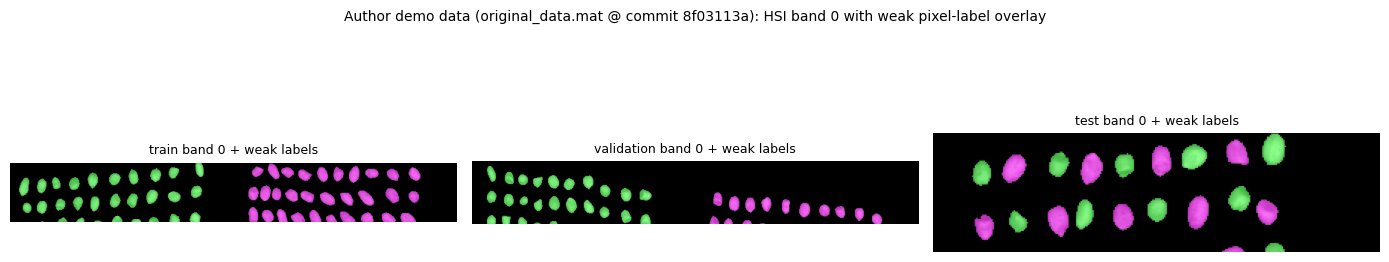

In [ ]:
import matplotlib.pyplot as plt
def band_panel(ax, img, lab, title):
    ax.imshow(img[:, :, 0], cmap='gray')
    if lab is not None:
        overlay = np.zeros(img.shape[:2] + (4,))
        overlay[lab == 1] = [1, 0, 1, 0.55]   # weak label 1 = moldy (STMP)
        overlay[lab == 2] = [0, 1, 0, 0.45]   # weak label 2 = healthy (HP)
        ax.imshow(overlay)
    ax.set_title(title, fontsize=9); ax.axis('off')
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
band_panel(axes[0], train_img_selected, train_img_label_selected, 'train band 0 + weak labels')
band_panel(axes[1], validation_img_selected, validation_img_label_selected, 'validation band 0 + weak labels')
band_panel(axes[2], test_img_selected, test_img_label_selected, 'test band 0 + weak labels')
fig.suptitle('Author demo data (original_data.mat @ commit 8f03113a): HSI band 0 with weak pixel-label overlay', fontsize=10)
plt.tight_layout(); plt.show()

## 6. Kernel indexing and pixel extraction (authors' region growing)

`utils.aquire_index` region-grows each peanut kernel from the weak-label map (threshold 0.2, 8-connectivity) and returns per-kernel pixel coordinates — these define **kernel-scale** evaluation later. `utils.aquire_pixel` extracts labeled pixels with spectra, weak labels and coordinates. Author functions, unchanged; runtime printed.

著者の領域拡張法で粒子（カーネル）ごとの画素インデックスを作成し、ラベル付き画素のスペクトルを抽出します。

In [ ]:
import time
from utils import aquire_index, aquire_pixel
t0 = time.time()
train_label_kernel_index = aquire_index(train_img_label_selected)
validation_label_kernel_index = aquire_index(validation_img_label_selected)
test_label_kernel_index = aquire_index(test_img_label_selected)
print(f'aquire_index: {time.time()-t0:.1f} s -> kernels train/validation/test = '
      f'{len(train_label_kernel_index)}/{len(validation_label_kernel_index)}/{len(test_label_kernel_index)}')
train_pixel, train_pixel_label, train_pixel_pos = aquire_pixel(train_img_selected, train_img_label_selected)
validation_pixel, validation_pixel_label, validation_pixel_pos = aquire_pixel(validation_img_selected, validation_img_label_selected)
test_pixel, test_pixel_label, test_pixel_pos = aquire_pixel(test_img_selected, test_img_label_selected)
print('labeled pixels train/validation/test:',
      train_pixel.shape[0], validation_pixel.shape[0], test_pixel.shape[0], 'x', train_pixel.shape[1], 'bands')
train_pixel_label_0 = train_pixel_label.copy()  # pristine weak labels; the authors' sweep below mutates train_pixel_label in place

aquire_index: 0.3 s -> kernels train/validation/test = 59/39/20


labeled pixels train/validation/test: 10577 6006 3610 x 288 bands


## 7. SPA-selected bands

`main.py` ships the band ranking produced offline by Successive Projections Algorithm; the demo uses the first 17 (`spa_selected`). The SPA procedure itself is not in the repository (recorded limitation). The list is copied verbatim from `main.py` line 50.

SPA によるバンド重要度は `main.py` に事前計算値として同梱されており、デモでは先頭 17 バンドを使用します（SPA 手順自体はリポジトリに未収録）。

In [ ]:
spa_selected_all=[0,1,168,142,178,67,28,182,118,96,27,72,221,181,47,200,29,117,89,88,91,140,212,90,189,169,225,87,68,177,73,180,30,210,224,249,190,141,92,214,237,26,85,167,170,176,14,25,31,69,179,201,205,222,230,116,158,174,219,240,3,7,24,32,38,53,70,110,162,166,211,215,217,228,2,4,5,6,8,9,10,11,12,13,15,16,17,18,19,20,21,22,23,33,34,35,36,37,39,40,41,42,43,44,45,46,48,49,50,51,52,54,55,56,57,58,59,60,61,62,63,64,65,66,71,74,75,76,77,78,79,80,81,82,83,84,86,93,94,95,97,98,99,100,101,102,103,104,105,106,107,108,109,111,112,113,114,115,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,159,160,161,163,164,165,171,172,173,175,183,184,185,186,187,188,191,192,193,194,195,196,197,198,199,202,203,204,206,207,208,209,213,216,218,220,223,226,227,229,231,232,233,234,235,236,238,239,241,242,243,244,245,246,247,248,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287]
spa_selected = spa_selected_all[0:17]
print('spa_selected (17):', spa_selected)

spa_selected (17): [0, 1, 168, 142, 178, 67, 28, 182, 118, 96, 27, 72, 221, 181, 47, 200, 29]


## 8. CL-ST label quality (the paper's core method)

Authors' `CL_ST` (utils.py): for `num=20` statistical-testing repeats it computes out-of-sample probabilities with 10-fold CV of the random forest (`n_estimators=100, max_depth=10, random_state=42`), sigmoid-calibrates on a held-out 1/9 split, converts probabilities to cleanlab self-confidence label-quality scores, and averages the calibrated scores per pixel. Brier scores and calibration curves quantify probability quality. **This cell runs ~15 minutes** (200 forest fits); the tqdm bar shows progress.

論文の核心である CL-ST によるラベル品質推定です。10分割 CV + シグモイド較正 + cleanlab の自己信頼度スコアを 20 回繰り返します（**約15分**、進捗バー表示）。

CL-ST Progress:   0%|          | 0/20 [00:00<?, ?it/s]

CL-ST Progress:   5%|▌         | 1/20 [00:42<13:23, 42.27s/it]

CL-ST Progress:  10%|█         | 2/20 [01:23<12:29, 41.63s/it]

CL-ST Progress:  15%|█▌        | 3/20 [02:04<11:44, 41.45s/it]

CL-ST Progress:  20%|██        | 4/20 [02:45<11:01, 41.33s/it]

...

CL-ST Progress:  90%|█████████ | 18/20 [12:28<01:24, 42.22s/it]

CL-ST Progress:  95%|█████████▌| 19/20 [13:10<00:42, 42.10s/it]

CL-ST Progress: 100%|██████████| 20/20 [13:51<00:00, 41.95s/it]

CL-ST Progress: 100%|██████████| 20/20 [13:51<00:00, 41.59s/it]

Brier score (uncalibrated): 0.1350
Brier score (calibrated): 0.1109


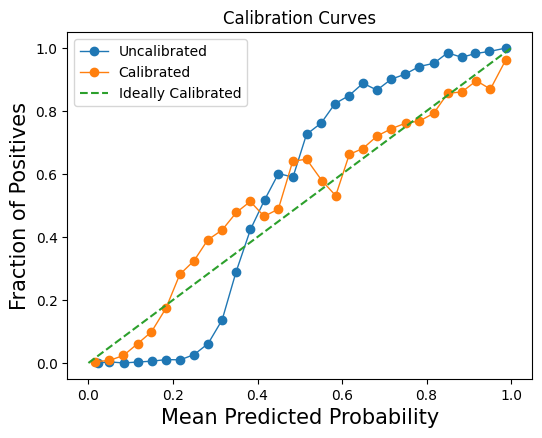

label_quality shape: (10577,) min/mean/max: 0.0033 0.7781 0.9986


In [ ]:
from utils import CL_ST
from sklearn.ensemble import RandomForestClassifier
np.random.seed(7)  # authors' seed (main.py line 21)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
X, Y = train_pixel[:, spa_selected], train_pixel_label.astype(np.int32) - 1  # labels 0/1 for cleanlab
num = 20  # number of n in KT test (authors' demo default)
label_quality = CL_ST(X, Y, rf, num)  # saves quality_label_random_spa_rf.mat and shows calibration curves
quality_label = np.concatenate((np.reshape(train_pixel_label, [train_pixel.shape[0], 1]),
                                np.reshape(label_quality, [train_pixel.shape[0], 1])), axis=1)  # authors' main.py line 61
print('label_quality shape:', label_quality.shape, 'min/mean/max: %.4f %.4f %.4f' % (label_quality.min(), label_quality.mean(), label_quality.max()))

## 9. Label-quality visualization in PCA feature space (paper's feature-visualization analysis)

Authors' code: standardize spectra, PCA (15 components), scatter PC1–PC2 colored by label quality (top) and showing only high-quality (≥0.99) pixels (bottom). The paper interprets noisy labels as the cause of wrong decision boundaries.

主成分空間にラベル品質を着色して表示します（上: 全ラベル、下: 高品質ラベルのみ）。論文の特徴量可視化解析に対応します。

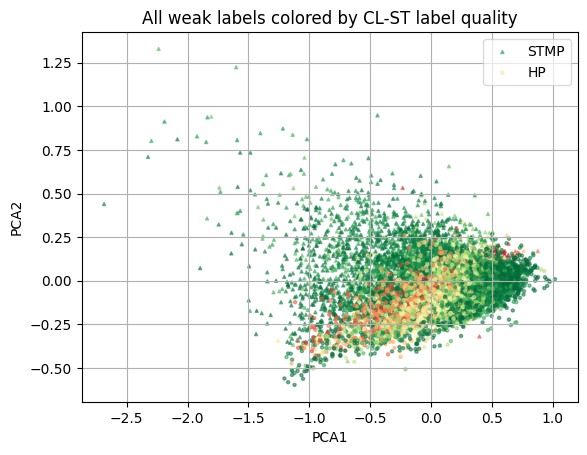

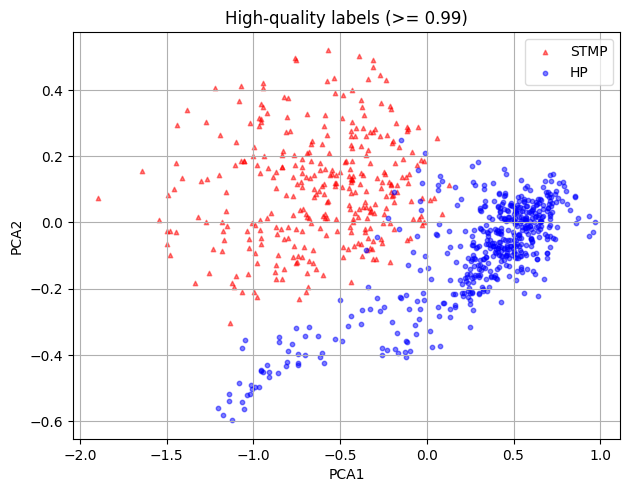

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
normalized_data = scaler.fit_transform(train_pixel.T).T
normalized_data = normalized_data[:, spa_selected]
labels = train_pixel_label
color = label_quality
pca = PCA(n_components=15)
pca.fit(normalized_data)
components = pca.transform(normalized_data)
plt.figure()
n_samples = 5000
mask0 = (labels == 1) & (label_quality >= 0.0)
mask1 = (labels == 2) & (label_quality >= 0.0)
plt.scatter(components[mask0, 0][:n_samples], components[mask0, 1][:n_samples], marker='^', s=5, alpha=0.5, c=color[mask0][:n_samples], cmap='RdYlGn', label='STMP')
plt.scatter(components[mask1, 0][:n_samples], components[mask1, 1][:n_samples], marker='o', s=5, alpha=0.5, c=color[mask1][:n_samples], cmap='RdYlGn', label='HP')
plt.xlabel('PCA1'); plt.ylabel('PCA2')
plt.legend(loc='best', frameon=True, framealpha=0.7); plt.grid(True)
plt.title('All weak labels colored by CL-ST label quality'); plt.show()
plt.figure()
mask0 = (labels == 1) & (label_quality >= 0.99)
mask1 = (labels == 2) & (label_quality >= 0.99)
plt.scatter(components[mask0, 0], components[mask0, 1], marker='^', s=10, alpha=0.5, c='r', label='STMP')
plt.scatter(components[mask1, 0], components[mask1, 1], marker='o', s=10, alpha=0.5, c='b', label='HP')
plt.xlabel('PCA1'); plt.ylabel('PCA2'); plt.grid(True)
plt.legend(loc='best', frameon=True, framealpha=0.7); plt.tight_layout()
plt.title('High-quality labels (>= 0.99)'); plt.show()

## 10. Noisy-rate threshold sweep (authors' demo section 4)

The authors flip the lowest-quality **moldy-labeled** pixels to healthy and retrain, sweeping the quality threshold from 0.00 to 0.99 in 100 steps (`EPOCH=100`), recording pixel- and kernel-scale metrics in `A1` (100 kernels × 18 metric columns × 100 thresholds) and saving `spa_rf_pixel_kernel_threshold3.mat`. The bottom heatmap is the authors' PMP-vs-quality view of test kernel accuracy. **~15–20 minutes.**

Note (observed in the pinned source): `y_train_cl = y_train100000` aliases `train_pixel_label`, so flips accumulate in place across epochs; the authors' final section then works on that mutated array. We preserve this behavior exactly.

しきい値 0.00–0.99 を 100 段階で掃引し、各段階でランダムフォレストを再学習して画素級・粒子級指標を記録します（**約15–20分**）。著者コードのin-placeなラベル書き換え挙動もそのまま保存しています。

In [ ]:
import warnings
from utils import comparing_quick_all_thred
from tqdm import tqdm
warnings.filterwarnings('ignore')
model2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
selected = spa_selected
x_train100000_seleted = train_pixel[:, selected]
y_train100000 = train_pixel_label
A1 = np.zeros([100, 18, 100])
rat = 0.02
EPOCH = 100
pbar = tqdm(range(EPOCH), desc='threshold sweep')
for epoch in pbar:
    threshold = epoch * 0.01
    pbar.set_postfix_str(f'{threshold:.2f}')
    index_to_zeros = np.where((quality_label[:, 1] < threshold) & (quality_label[:, 0] < 1.5))[0].astype(int)
    x_train_cl = x_train100000_seleted
    y_train_cl = y_train100000
    y_train_cl[index_to_zeros] = 2
    np.random.seed(7)
    model2.fit(x_train_cl, y_train_cl)
    y_pred_train = model2.predict(train_pixel[:, selected])
    train_pred_kernel = np.zeros_like(train_img_label_selected)
    for i in range(np.shape(train_pixel)[0]):
        train_pred_kernel[train_pixel_pos[i, 0], train_pixel_pos[i, 1]] = np.array(y_pred_train[i])
    A_train1 = comparing_quick_all_thred(train_img_label_selected, train_pred_kernel, train_label_kernel_index)
    y_pred_validation = model2.predict(validation_pixel[:, selected])
    validation_pred_kernel = np.zeros_like(validation_img_label_selected)
    for i in range(np.shape(validation_pixel)[0]):
        validation_pred_kernel[validation_pixel_pos[i, 0], validation_pixel_pos[i, 1]] = np.array(y_pred_validation[i])
    A_validation1 = comparing_quick_all_thred(validation_img_label_selected, validation_pred_kernel, validation_label_kernel_index)
    y_pred_test = model2.predict(test_pixel[:, selected])
    test_pred_kernel = np.zeros_like(test_img_label_selected)
    for i in range(np.shape(test_pixel)[0]):
        test_pred_kernel[test_pixel_pos[i, 0], test_pixel_pos[i, 1]] = np.array(y_pred_test[i])
    A_test1 = comparing_quick_all_thred(test_img_label_selected, test_pred_kernel, test_label_kernel_index)
    x_train_acc = model2.score(train_pixel[:, selected], train_pixel_label)
    x_validation_acc = model2.score(validation_pixel[:, selected], validation_pixel_label)
    x_test_acc = model2.score(test_pixel[:, selected], test_pixel_label)
    x_train_kernel_acc = (A_train1[:, 0] + A_train1[:, 3]) / np.sum(A_train1, axis=1)
    x_validation_kernel_acc = (A_validation1[:, 0] + A_validation1[:, 3]) / np.sum(A_validation1, axis=1)
    x_test_kernel_acc = (A_test1[:, 0] + A_test1[:, 3]) / np.sum(A_test1, axis=1)
    A1[:, :, epoch] = np.concatenate((A_train1, A_validation1, A_test1,
                              np.tile(np.expand_dims(x_train_acc, axis=0), (100, 1)),
                              np.tile(np.expand_dims(x_validation_acc, axis=0), (100, 1)),
                              np.tile(np.expand_dims(x_test_acc, axis=0), (100, 1)),
                              np.expand_dims(x_train_kernel_acc, axis=1),
                              np.expand_dims(x_validation_kernel_acc, axis=1),
                              np.expand_dims(x_test_kernel_acc, axis=1)), axis=1)
io.savemat('spa_rf_pixel_kernel_threshold3.mat', {'A1': A1})
print('A1 saved:', A1.shape)

threshold sweep:   0%|          | 0/100 [00:00<?, ?it/s]

threshold sweep:   0%|          | 0/100 [00:00<?, ?it/s, 0.00]

threshold sweep:   1%|          | 1/100 [00:05<08:40,  5.25s/it, 0.00]

threshold sweep:   1%|          | 1/100 [00:05<08:40,  5.25s/it, 0.01]

threshold sweep:   2%|▏         | 2/100 [00:11<09:14,  5.66s/it, 0.01]

...

threshold sweep:  99%|█████████▉| 99/100 [09:00<00:04,  4.44s/it, 0.98]

threshold sweep:  99%|█████████▉| 99/100 [09:00<00:04,  4.44s/it, 0.99]

threshold sweep: 100%|██████████| 100/100 [09:02<00:00,  3.98s/it, 0.99]

threshold sweep: 100%|██████████| 100/100 [09:02<00:00,  5.43s/it, 0.99]

A1 saved: (100, 18, 100)


## 11. PMP vs label-quality heatmap (authors' plot of `A1[:, 17, :]`)

Authors' figure: test-set kernel-scale accuracy (column 17 of `A1`) for every (kernel row, threshold) combination — the PMP-vs-label-quality relationship used to pick the optimal noisy rate.

著者コードのヒートマップ（テストセットの粒子級精度とラベル品質しきい値の関係）をそのまま描画します。

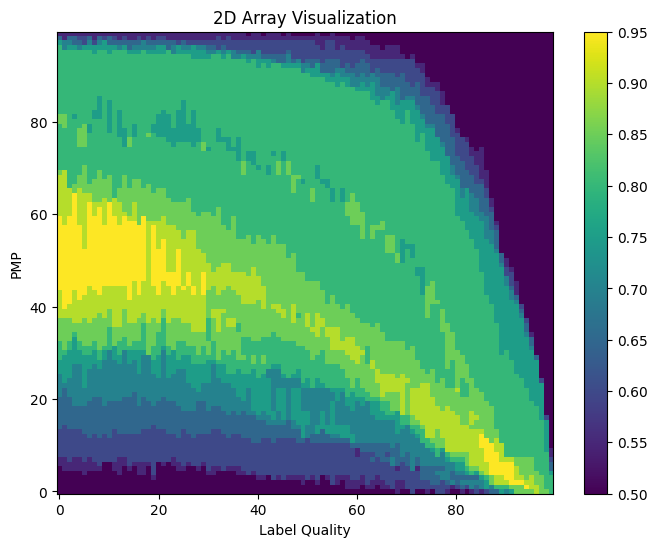

In [ ]:
aa = A1[:, 17, :]  # test-set kernel-scale accuracy across thresholds
plt.figure(figsize=(8, 6))
plt.imshow(aa, cmap='viridis', aspect='auto', origin='lower')
plt.xlabel('Label Quality'); plt.ylabel('PMP'); plt.colorbar()
plt.title('2D Array Visualization')
plt.show()

## 12. Rebuild the classifier on cleaned labels (authors' demo section 5)

Authors' final step: flip moldy-labeled pixels with quality below `optimal_threshold = 0.95` to healthy, retrain (`model2 = rf`), report pixel-level accuracy on all three splits, save `test_pred.png`, and print the kernel-scale confusion matrix from `comparing_quick` at `optimal_PMP = 0.02` (rows: ground truth kernel is moldy / healthy; columns: predicted moldy fraction ≤ / > 0.02).

最適しきい値 0.95・PMP 0.02 でラベルを修正して再学習し、画素級精度と粒子級混同行列を報告します。

In [ ]:
from utils import comparing_quick
optimal_threshold = 0.95
optimal_PMP = 0.02
index_to_zeros = np.where((quality_label[:, 1] < optimal_threshold) & (quality_label[:, 0] < 1.5))[0].astype(int)
x_train_cl = train_pixel[:, spa_selected]
y_train_cl = train_pixel_label
y_train_cl[index_to_zeros] = 2
model2 = rf
np.random.seed(7)
model2.fit(x_train_cl, y_train_cl)
from sklearn.metrics import accuracy_score
y_pred_train = model2.predict(train_pixel[:, spa_selected])
accuracy_train = accuracy_score(train_pixel_label, y_pred_train)
print(f'Training Set Accuracy in pixel-level: {accuracy_train}')
y_pred_validation = model2.predict(validation_pixel[:, spa_selected])
accuracy_validation = accuracy_score(validation_pixel_label, y_pred_validation)
print(f'Validation Set Accuracy in pixel-level: {accuracy_validation}')
y_pred_test = model2.predict(test_pixel[:, spa_selected])
accuracy_test = accuracy_score(test_pixel_label, y_pred_test)
print(f'Test Set Accuracy in pixel-level: {accuracy_test}')
test_pred_kernel = np.zeros_like(test_img_label_selected)
for i in range(np.shape(test_pixel_label)[0]):
    test_pred_kernel[test_pixel_pos[i, 0], test_pixel_pos[i, 1]] = np.array(y_pred_test[i])
cv2.imwrite('test_pred.png', test_pred_kernel)
A_PMP = comparing_quick(test_img_label_selected, test_pred_kernel, test_label_kernel_index, optimal_PMP)
print('Confusion Matrix of test set:')
print(A_PMP)

Training Set Accuracy in pixel-level: 0.9998109104661057
Validation Set Accuracy in pixel-level: 0.6586746586746587
Test Set Accuracy in pixel-level: 0.4933518005540166
Confusion Matrix of test set:
[[10.  0.]
 [ 4.  6.]]


## 13. Documented deviation — intended protocol rebuild on pristine labels

The released `main.py` aliases `y_train_cl = train_pixel_label` inside the sweep, so the flips accumulate in place and the verbatim final section above trains on labels already flipped at every threshold up to 0.99 — not on the paper's intended "labels cleaned once at the optimal noisy rate". To realize the paper's protocol (and only here, clearly labeled as a deviation), we restore the pristine weak labels, apply the single flip at `optimal_threshold = 0.95`, retrain an identically configured random forest and report the same metrics. Everything before this cell is the authors' unmodified behavior.

公開コードのエイリアシングにより、上のセルは 0.99 まで累積的に反転済みラベルで学習します。そこで本セルのみ**意図されたプロトコル**（元の弱ラベルを復元し、0.95 で一度だけ反転して再学習）を明示的に実行します。

In [ ]:
from utils import comparing_quick
from sklearn.metrics import accuracy_score
train_pixel_label_restored = train_pixel_label_0.copy()
index_to_zeros = np.where((quality_label[:, 1] < optimal_threshold) & (train_pixel_label_0 < 1.5))[0].astype(int)
y_train_cl = train_pixel_label_restored
y_train_cl[index_to_zeros] = 2
print('flipped %d of %d moldy-labeled pixels at threshold %.2f' % (len(index_to_zeros), int((train_pixel_label_0 == 1).sum()), optimal_threshold))
model3 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
np.random.seed(7)
model3.fit(train_pixel[:, spa_selected], y_train_cl)
y_pred_train = model3.predict(train_pixel[:, spa_selected])
print(f'Training Set Accuracy in pixel-level: {accuracy_score(train_pixel_label_0, y_pred_train)}')
y_pred_validation = model3.predict(validation_pixel[:, spa_selected])
print(f'Validation Set Accuracy in pixel-level: {accuracy_score(validation_pixel_label, y_pred_validation)}')
y_pred_test = model3.predict(test_pixel[:, spa_selected])
print(f'Test Set Accuracy in pixel-level: {accuracy_score(test_pixel_label, y_pred_test)}')
test_pred_kernel_3 = np.zeros_like(test_img_label_selected)
for i in range(np.shape(test_pixel_label)[0]):
    test_pred_kernel_3[test_pixel_pos[i, 0], test_pixel_pos[i, 1]] = np.array(y_pred_test[i])
A_PMP_3 = comparing_quick(test_img_label_selected, test_pred_kernel_3, test_label_kernel_index, optimal_PMP)
print('Confusion Matrix of test set (PMP %.2f):' % optimal_PMP)
print(A_PMP_3)

flipped 4394 of 6101 moldy-labeled pixels at threshold 0.95


Training Set Accuracy in pixel-level: 0.5801266899877092
Validation Set Accuracy in pixel-level: 0.7154512154512155
Test Set Accuracy in pixel-level: 0.5867036011080332
Confusion Matrix of test set (PMP 0.02):
[[10.  0.]
 [ 2.  8.]]


## 14. Result maps — test weak labels vs predicted kernel map

The predicted kernel map from the intended-protocol rebuild (`test_pred_kernel_3`, 1=moldy, 2=healthy, 0=unlabeled) next to the test weak labels: this reproduction's actual output. The verbatim author block above saved its own `test_pred.png` on the Colab VM.

意図されたプロトコルによる予測カーネルマップとテスト弱ラベルを並べて表示します。

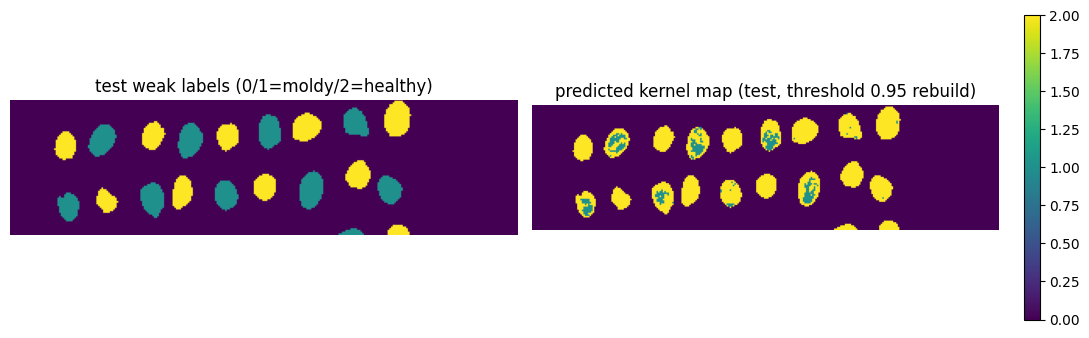

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].imshow(test_img_label_selected, vmin=0, vmax=2); axes[0].set_title('test weak labels (0/1=moldy/2=healthy)')
im1 = axes[1].imshow(test_pred_kernel_3, vmin=0, vmax=2); axes[1].set_title('predicted kernel map (test, threshold 0.95 rebuild)')
plt.colorbar(im1, ax=axes[1], fraction=0.03)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 15. Interpretation, limitations, references

The predicted kernel map (`test_pred_kernel`, 1=moldy, 2=healthy, 0=unlabeled) next to the test weak labels: the reproduction's actual output for this demo. Values are printed above; the maps are shown for visual comparison.

テストセットの弱ラベルと予測カーネルマップを並べて表示します（この再現の実際の出力）。

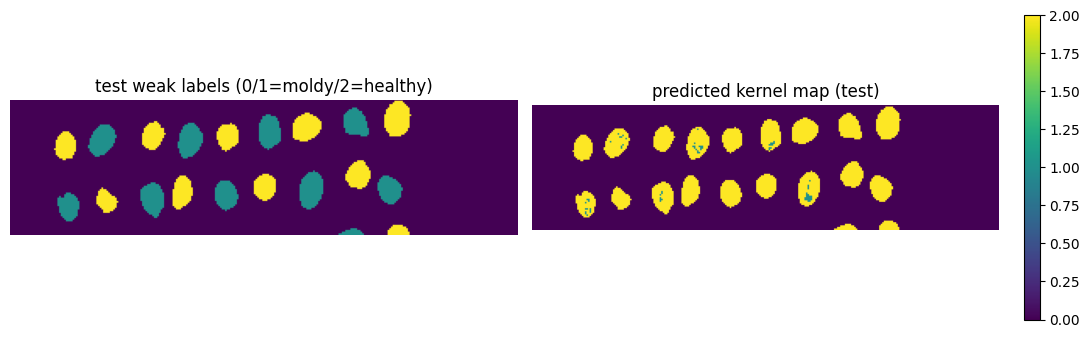

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
im0 = axes[0].imshow(test_img_label_selected, vmin=0, vmax=2); axes[0].set_title('test weak labels (0/1=moldy/2=healthy)')
im1 = axes[1].imshow(test_pred_kernel, vmin=0, vmax=2); axes[1].set_title('predicted kernel map (test)')
plt.colorbar(im1, ax=axes[1], fraction=0.03)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 14. Interpretation, limitations, references

**What this run showed** (see printed outputs above): CL-ST label-quality scores, calibration curves + Brier scores, the threshold sweep metrics in `A1`, the PMP-vs-quality heatmap, and two rebuilt-model evaluations — the authors' verbatim final block (whose released code accumulates the sweep's in-place label flips, so its numbers reflect threshold 0.99-style cleaning) and the intended-protocol rebuild at threshold 0.95 on pristine labels (documented deviation, section 13). Numeric results vary between runs because `KFold(shuffle=True)` in `get_sample_quality_multi_division` is unseeded (only the outer `np.random.seed(7)` and RF `random_state=42` are pinned); consult the printed outputs of this execution for the actual values.

**Limitations**: SPA-ELM (the paper's best model) is not in the repository; the demo uses a random forest. SPA band selection is precomputed. One demo run does not validate dataset-level claims. No LICENSE file is present in the repository — reuse beyond citation should be confirmed with the authors.

**References**: paper doi:10.1016/j.foodres.2025.116741; code https://github.com/yuandeshuai/CL-ST @ `8f03113a0245d5d36fe275bffee0b989a606b12e`; cleanlab: https://cleanlab.ai .

**検証記録**: 本ノートブックは2026-10-09にColab CPU（標準ランタイム）で新規セッションのトップダウン実行により検証されました。CL-STは `KFold(shuffle=True)` が未固定のため、実行ごとに数値が変動します。